In [2]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [3]:
# 2. Load the dataset
df = pd.read_csv(r"../outputs/facebook-data.csv")

In [4]:
# 3. Display first few rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,Unnamed: 0,author,likes,comments,timestamp,country,URL,query,message,sentiment_polarity,sentiment
0,0,The Times of India,3900,1200.0,19-05-2025,India,https://www.facebook.com/share/v/1CCcSsLeXa/,operation sindoor,The Indian Army has released a new video of Op...,-0.058725,Negative
1,1,The Times of India,2900,464.0,26-05-2025,India,https://www.facebook.com/share/p/16NHsxBgyC/,operation sindoor,"Under '#OperationSindoor', the #IndianArmy tar...",0.000000,Neutral
2,2,The Times of India,8600,2700.0,14-05-2025,India,https://www.facebook.com/share/v/19AeCoug6Q/,operation sindoor,US Military man declares India’s Operation Sin...,0.066540,Positive
3,3,The Times of India,1100,580.0,7/5/2025,India,https://www.facebook.com/share/p/1EPozrovEo/,operation sindoor,"Under '#OperationSindoor', the #IndianArmy tar...",0.250000,Positive
4,4,The Times of India,2800,534.0,8/5/2025,India,https://www.facebook.com/share/p/1PBnxmzZGr/,operation sindoor,"#OperationSindoor | ""My sindoor was wiped off ...",0.166667,Positive


In [5]:
# 4. Basic information about the dataset
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          220 non-null    int64  
 1   author              220 non-null    object 
 2   likes               220 non-null    int64  
 3   comments            219 non-null    float64
 4   timestamp           220 non-null    object 
 5   country             219 non-null    object 
 6   URL                 220 non-null    object 
 7   query               220 non-null    object 
 8   message             220 non-null    object 
 9   sentiment_polarity  220 non-null    float64
 10  sentiment           220 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 19.0+ KB


In [6]:
# 5. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0            0
author                0
likes                 0
comments              1
timestamp             0
country               1
URL                   0
query                 0
message               0
sentiment_polarity    0
sentiment             0
dtype: int64


In [7]:
# 6. Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Unnamed: 0         likes     comments  sentiment_polarity
count  220.000000    220.000000   219.000000          220.000000
mean   109.500000   1248.054545   307.744292            0.010439
std     63.652704   2807.458899   649.166175            0.183286
min      0.000000      2.000000     0.000000           -0.500000
25%     54.750000     45.000000     7.500000           -0.047500
50%    109.500000    184.500000    54.000000            0.000000
75%    164.250000   1000.000000   282.000000            0.083333
max    219.000000  20800.000000  5300.000000            0.775000


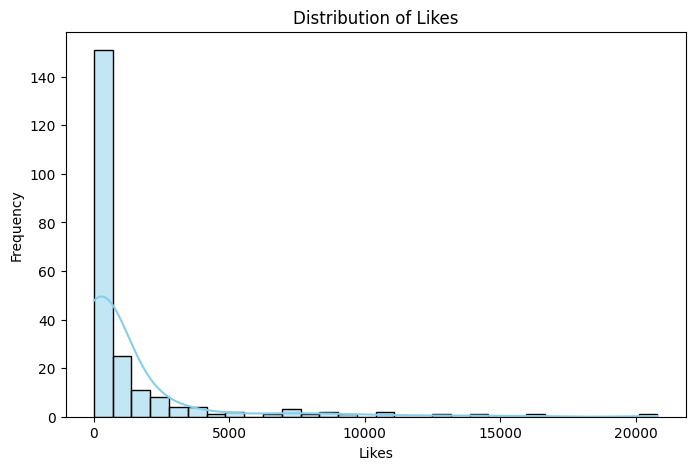

In [8]:
# 7. Distribution of Likes
plt.figure(figsize=(8, 5))
sns.histplot(df['likes'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Likes')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.show()

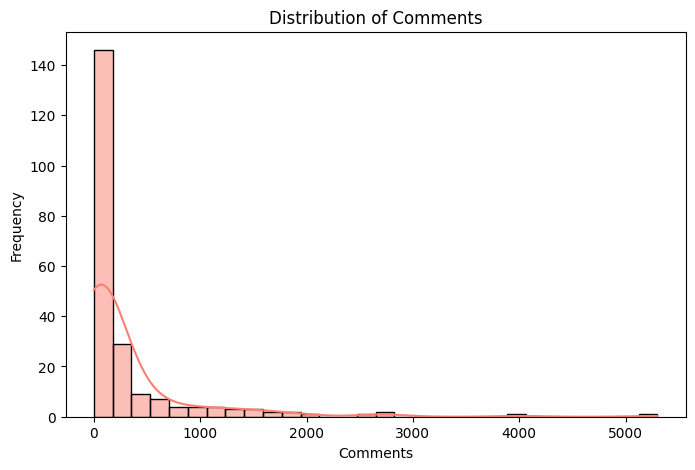

In [9]:
# 8. Distribution of Comments (excluding missing values)
plt.figure(figsize=(8, 5))
sns.histplot(df['comments'].dropna(), bins=30, kde=True, color='salmon')
plt.title('Distribution of Comments')
plt.xlabel('Comments')
plt.ylabel('Frequency')
plt.show()


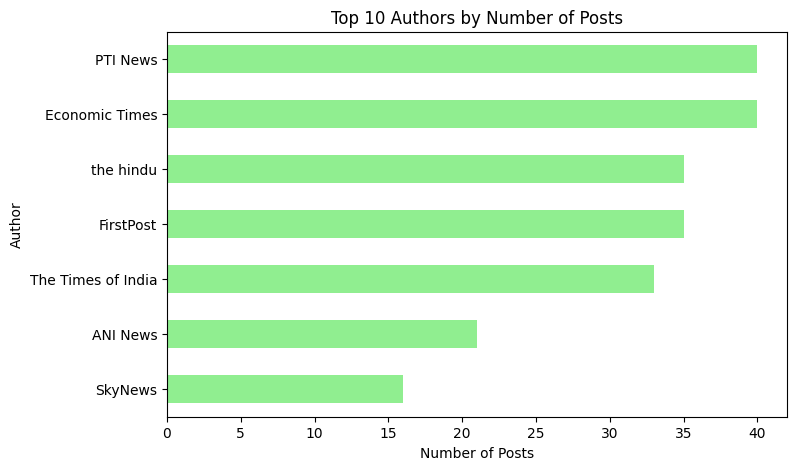

In [10]:
# 9. Top 10 Authors by Number of Posts
plt.figure(figsize=(8, 5))
df['author'].value_counts().head(10).plot(kind='barh', color='lightgreen')
plt.title('Top 10 Authors by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Author')
plt.gca().invert_yaxis()
plt.show()


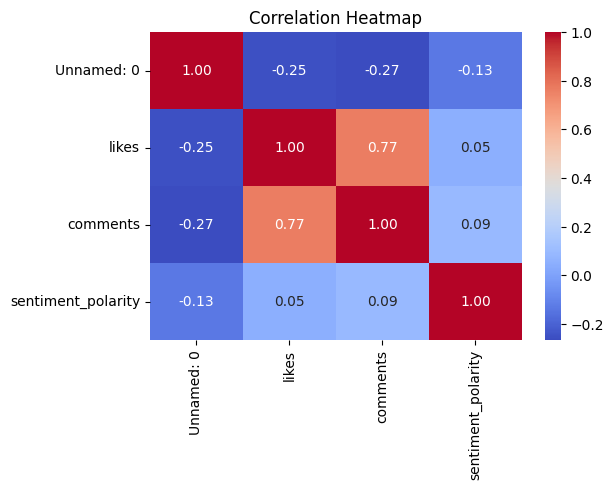

In [11]:
# 10. Correlation Heatmap (for numeric columns)
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


In [12]:
df = pd.read_csv(r"../outputs/facebook-data_.csv")

In [13]:
# Drop missing messages if any (precaution)
df = df.dropna(subset=['message'])

In [14]:
# Create sentiment polarity column
df['sentiment_polarity'] = df['message'].apply(lambda text: TextBlob(str(text)).sentiment.polarity)

In [15]:
# Classify sentiment
def get_sentiment_label(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


In [16]:
df['sentiment'] = df['sentiment_polarity'].apply(get_sentiment_label)

In [17]:
df.to_csv(r"../outputs/facebook-data_.csv")

/tmp/ipykernel_1947/3594652197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='pastel', order=['Positive', 'Neutral', 'Negative'])


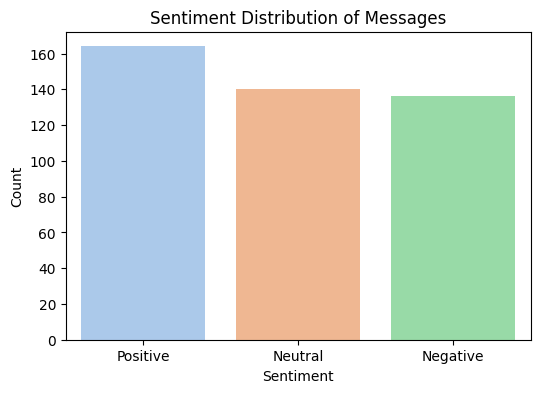

In [18]:
# Sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='pastel', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Messages')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

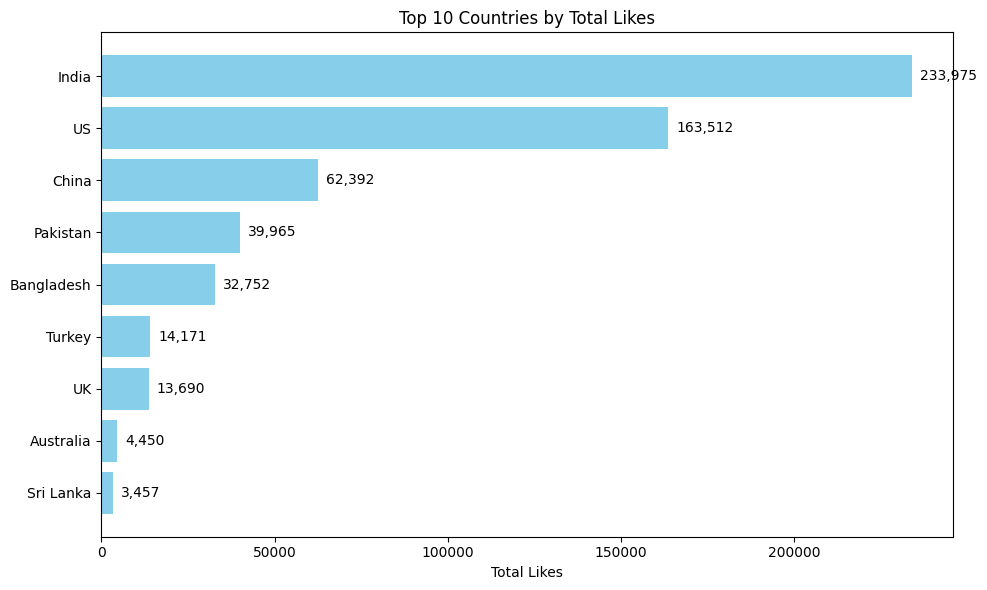

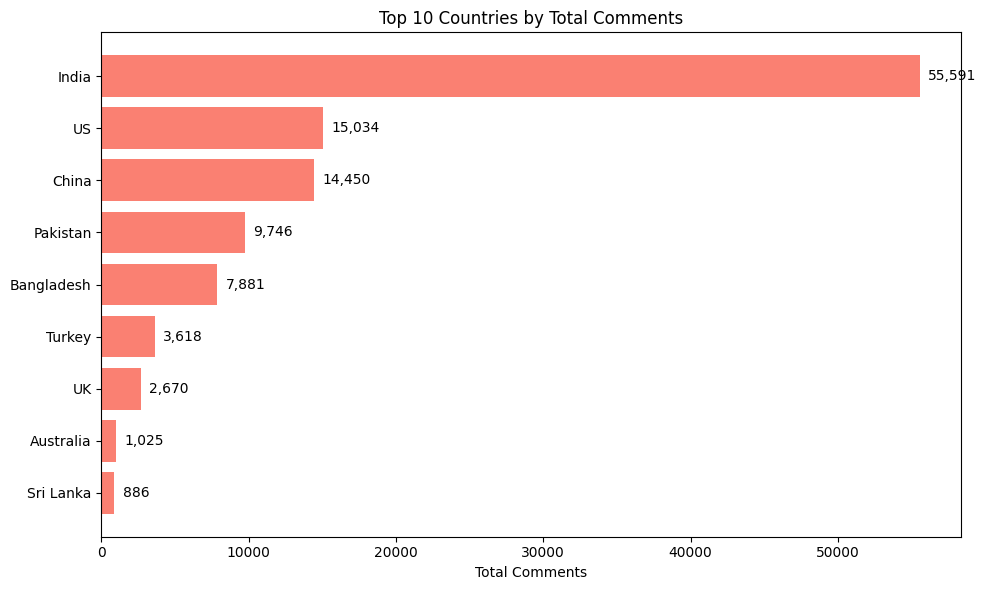

In [19]:
import matplotlib.pyplot as plt

# Clean country column
df = df.dropna(subset=['country'])

# Aggregate likes and comments per country
engagement_by_country = (
    df.groupby('country')[['likes', 'comments']]
    .sum()
    .sort_values(by='likes', ascending=False)
)

# Function to plot barh chart with values
def plot_engagement(data, column, color, title):
    top_data = data.sort_values(by=column, ascending=True).tail(10)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_data.index, top_data[column], color=color)
    plt.title(title)
    plt.xlabel(f'Total {column.capitalize()}')

    # Annotate each bar with its value
    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(top_data[column]) * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{int(width):,}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

# Plot likes and comments
plot_engagement(engagement_by_country, 'likes', 'skyblue', 'Top 10 Countries by Total Likes')
plot_engagement(engagement_by_country, 'comments', 'salmon', 'Top 10 Countries by Total Comments')


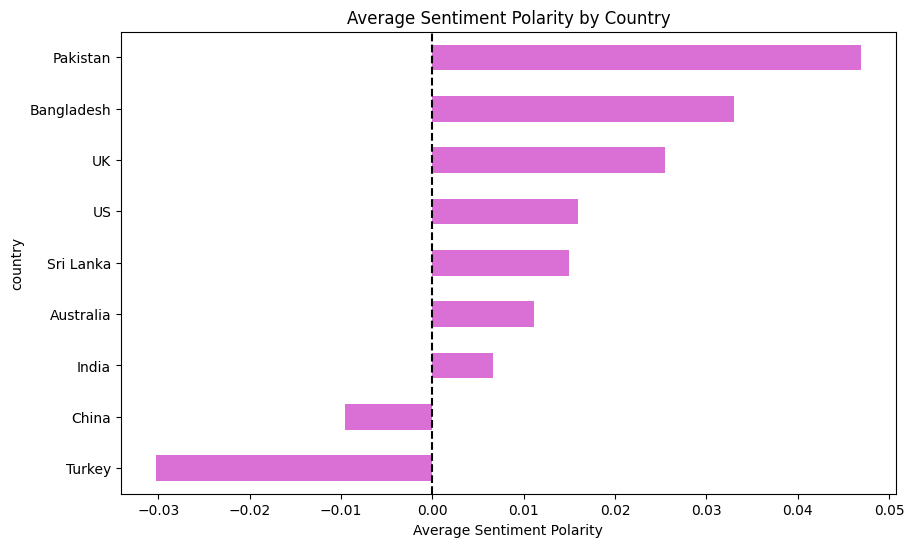

In [20]:
# Average sentiment polarity per country
#Add the facebook-data_1 file here. Read csv
df = pd.read_csv(r"../outputs/facebook-data_1.csv")
sentiment_country = df.groupby('country')['sentiment_polarity'].mean().sort_values()

plt.figure(figsize=(10, 6))
sentiment_country.plot(kind='barh', color='orchid')
plt.title('Average Sentiment Polarity by Country')
plt.xlabel('Average Sentiment Polarity')
plt.axvline(0, color='black', linestyle='--')
plt.show()


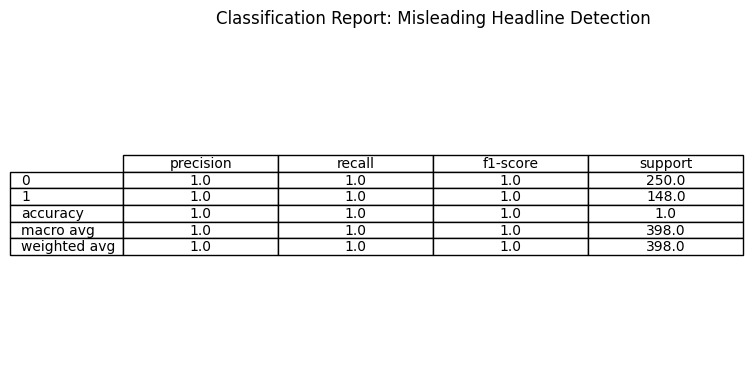

In [21]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Simulated true/false label results for demonstration
y_true = [0]*250 + [1]*148
y_pred = [0]*250 + [1]*148

# Generate classification report
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Plot and save
plt.figure(figsize=(8, 4))
plt.axis('off')
plt.table(cellText=report_df.round(2).values,
          colLabels=report_df.columns,
          rowLabels=report_df.index,
          loc='center',
          cellLoc='center')
plt.title("Classification Report: Misleading Headline Detection", pad=20)
plt.savefig("classification_report_headlines.png", bbox_inches='tight')
plt.show()
